# Lattice-Based Ecological Model

**Methods:** Stochastic cellular automaton (plant-herbivore-predator dynamics on a lattice with periodic boundaries); Python, Matplotlib

### Overview
This notebook simulates plant-herbivore-predator dynamics on a lattice, starting from seed-dispersal patterns and extending to a predator (fox) that pursues herbivores (rabbits) which evade it.

---

#### Neighborhood vs. global seed dispersal

The model is used to simulate both seed dispersal from each site to its neighboring sites case and randomly disperse across empty sites case.

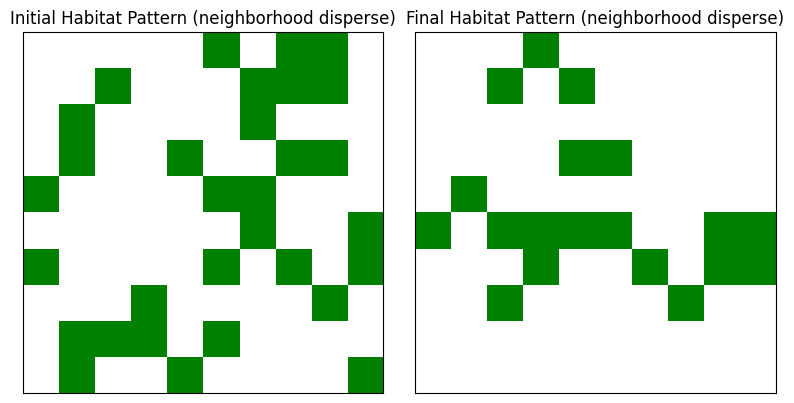

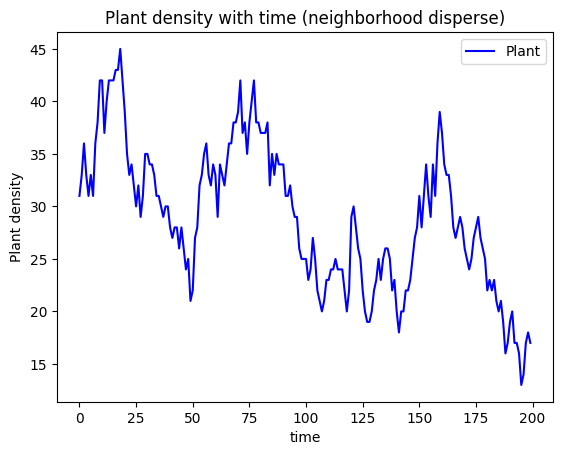

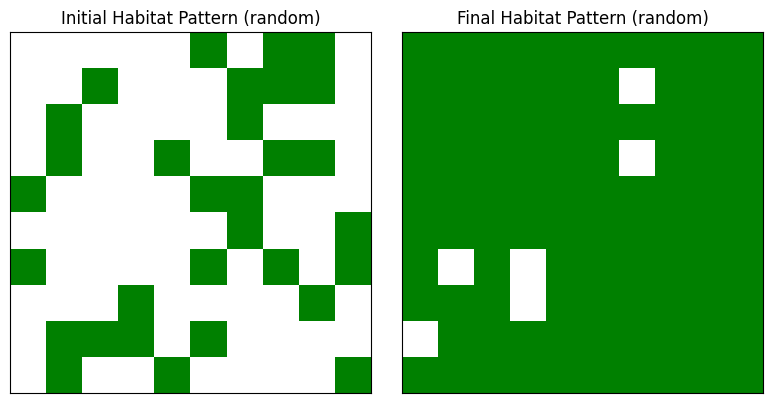

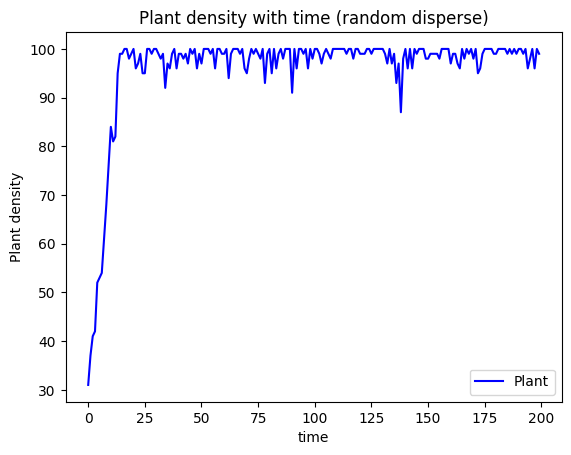

In [1]:
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import copy
import numpy as np

size = 10
laststep = 200

Plantdensity_neigh = [None for i in range(0, laststep)]
Plantdensity_rand  = [None for i in range(0, laststep)]

time = [None for i in range(0, laststep)]

# habitat for neighborhood disperse
habitat = [[0 for i in range(0, size)] for j in range(0, size)]

# habitat for random disperse (global)
habitat_random = [[0 for i in range(0, size)] for j in range(0, size)]

growthprob = 0.2
deathprob = 0.1
Plantinitial = 0.3

# Function for neighborhood dispersal
def disperse_neighborhood(current_habitat, parent_i, parent_j, lattice_size):
  ic = random.randrange(-1, 2)
  jc = random.randrange(-1, 2)

  if ic*ic + jc*jc > 0:
    inext = parent_i + ic
    if inext < 0:
      inext = lattice_size - 1
    elif inext >= lattice_size:
      inext = 0

    jnext = parent_j + jc
    if jnext < 0:
      jnext = lattice_size - 1
    elif jnext >= lattice_size:
      jnext = 0

    if current_habitat[inext][jnext] == 0:
      current_habitat[inext][jnext] = 1

# Function for random dispersal across empty sites
def disperse_random_empty(current_habitat, lattice_size):
  empty_sites = []
  for r_i in range(lattice_size):
    for r_j in range(lattice_size):
      if current_habitat[r_i][r_j] == 0:
        empty_sites.append((r_i, r_j))

  if empty_sites:
    new_plant_i, new_plant_j = random.choice(empty_sites)
    current_habitat[new_plant_i][new_plant_j] = 1

# I want to set initial pattern to be the same
for i in range(0, size):
  for j in range(0, size):
    r = random.random()
    if r < Plantinitial:
      habitat[i][j] = 1            # Plant (neighborhood)
      habitat_random[i][j] = 1     # Plant (random)

# Store the initial habitat state (for call to comparison at the end)
initial_habitat = copy.deepcopy(habitat)
initial_habitat_random = copy.deepcopy(habitat_random)

cmap = ListedColormap(['white', 'green'])

for t in range(0, laststep):

  Ptotal_neigh = 0
  Ptotal_rand  = 0

  for i in range(0, size):
    for j in range(0, size):
      if habitat[i][j] == 1:
        Ptotal_neigh += 1
      if habitat_random[i][j] == 1:
        Ptotal_rand += 1

  Plantdensity_neigh[t] = Ptotal_neigh
  Plantdensity_rand[t]  = Ptotal_rand
  time[t] = t

  # random sequential update
  for step in range(0, size * size):
    ii = random.randrange(0, size)
    jj = random.randrange(0, size)

    # ---------- neighborhood disperse ----------
    if habitat[ii][jj] == 1:  # plant
      if random.random() < deathprob:  # death
        habitat[ii][jj] = 0
      else:  # survive
        if random.random() < growthprob:  # reproduction
          disperse_neighborhood(habitat, ii, jj, size)

    # ---------- random disperse ----------
    if habitat_random[ii][jj] == 1:  # plant
      if random.random() < deathprob:  # death
        habitat_random[ii][jj] = 0
      else:  # survive
        if random.random() < growthprob:  # reproduction
          disperse_random_empty(habitat_random, size)

# patterns (neighborhood)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].matshow(initial_habitat, cmap=cmap)
axes[0].set_title('Initial Habitat Pattern (neighborhood disperse)')
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].matshow(habitat, cmap=cmap)
axes[1].set_title('Final Habitat Pattern (neighborhood disperse)')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

# density plot (neighborhood)
plt.plot(time, Plantdensity_neigh, c="blue", label='Plant')
plt.title('Plant density with time (neighborhood disperse)')
plt.xlabel('time')
plt.ylabel('Plant density')
plt.legend()
plt.show()

# patterns (random)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].matshow(initial_habitat_random, cmap=cmap)
axes[0].set_title('Initial Habitat Pattern (random)')
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].matshow(habitat_random, cmap=cmap)
axes[1].set_title('Final Habitat Pattern (random)')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

# density plot (random)
plt.plot(time, Plantdensity_rand, c="blue", label='Plant')
plt.title('Plant density with time (random disperse)')
plt.xlabel('time')
plt.ylabel('Plant density')
plt.legend()
plt.show()

The initial death probability is set to `0.05`, which is hard to distinguish between these 2 case; so, I increase the death probability to `0.1`. Now, we can see that the difference between these two cases is that the case where seeds disperse to the neighborhood population size is decaying as time goes on, while the case where seeds disperse across empty sites rapidly increases and covers the site within a time interval of 25.

---

### Testing the plant-rabbit system with various parameter values


Creating cases of parameters

In [2]:
cases = [
  {
    "label": "$P_G = 0.5, P_D = 0.1, P_I = 0.5, R_G = 0.6, R_D = 0.1, R_I = 0.5, R_M = 0.0$",
    "params": dict(growthprob = 0.5, deathprob = 0.1, Plantinitial = 0.5, growthprobR = 0.6, deathprobR = 0.1, Rabbitinitial = 0.5, moveprobR = 0)
  },
  {
    "label": "$P_G = 0.5, P_D = 0.1, P_I = 0.5, R_G = 0.6, R_D = 0.1, R_I = 0.5, R_M = 0.7$",
    "params": dict(growthprob = 0.5, deathprob = 0.1, Plantinitial = 0.5, growthprobR = 0.6, deathprobR = 0.1, Rabbitinitial = 0.5, moveprobR = 0.7)
  },
  {
    "label": "$P_G = 0.5, P_D = 0.1, P_I = 0.5, R_G = 0.6, R_D = 0.3, R_I = 0.5, R_M = 0.5$",
    "params": dict(growthprob = 0.5, deathprob = 0.1, Plantinitial = 0.5, growthprobR = 0.6, deathprobR = 0.3, Rabbitinitial = 0.5, moveprobR = 0.5)
  },
  {
    "label": "$P_G = 0.5, P_D = 0.1, P_I = 0.5, R_G = 0.6, R_D = 0.4, R_I = 0.5, R_M = 0.5$",
    "params": dict(growthprob = 0.5, deathprob = 0.1, Plantinitial = 0.5, growthprobR = 0.6, deathprobR = 0.4, Rabbitinitial = 0.5, moveprobR = 0.5)
  },
  {
    "label": "$P_G = 1.0, P_D = 0.1, P_I = 0.5, R_G = 0.5, R_D = 0.2, R_I = 0.5, R_M = 0.5$",
    "params": dict(growthprob = 1.0, deathprob = 0.1, Plantinitial = 0.5, growthprobR = 0.5, deathprobR = 0.2, Rabbitinitial = 0.5, moveprobR = 0.5)
  }
]


Begin the program

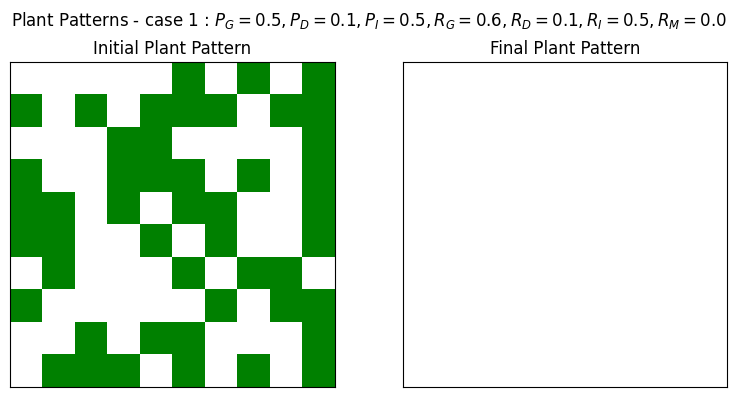

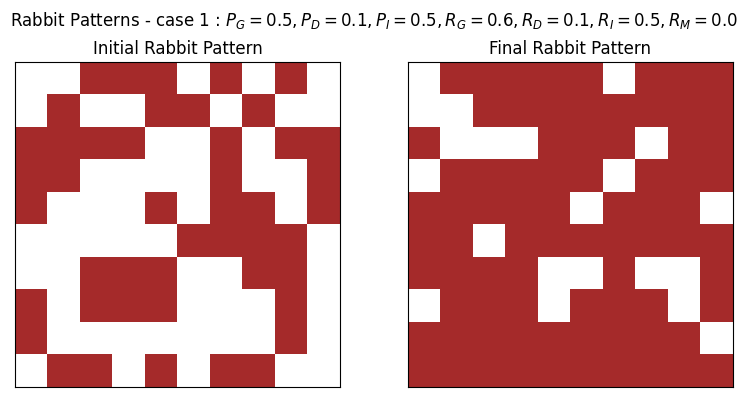

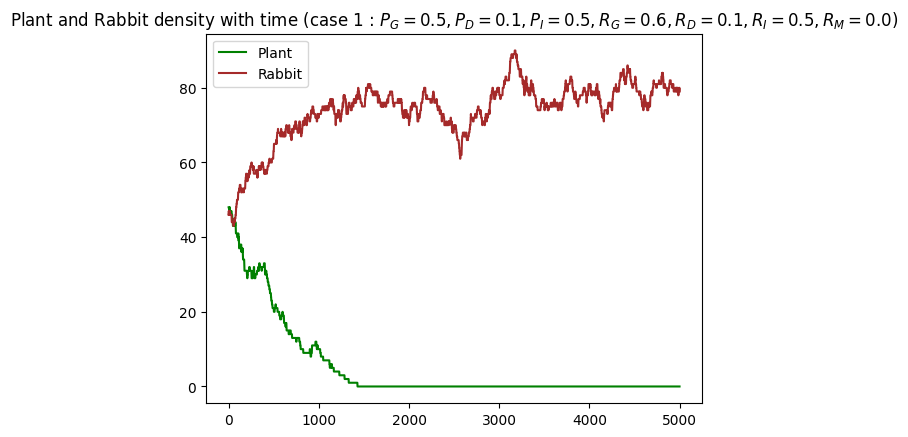

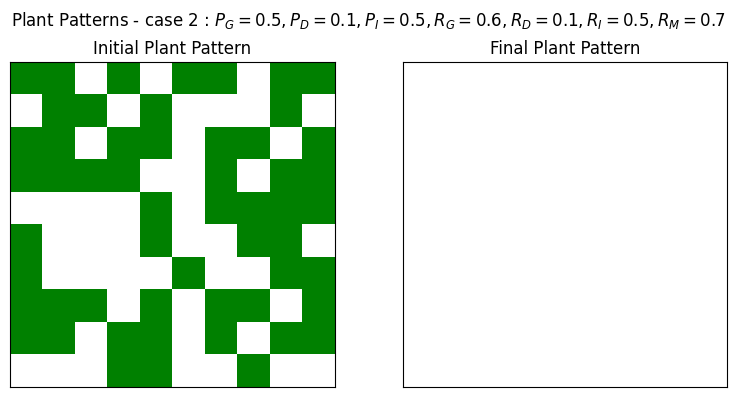

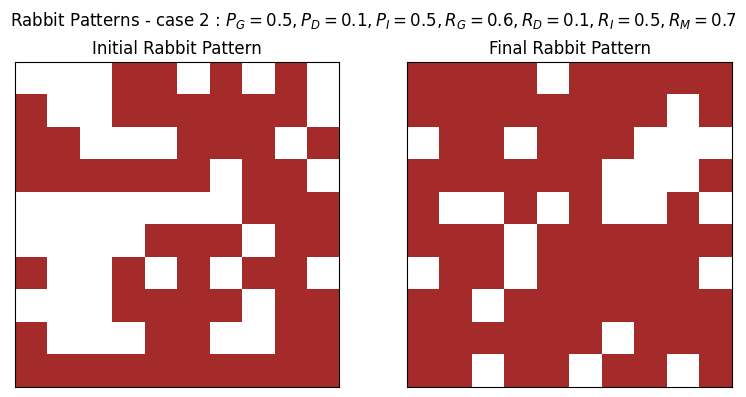

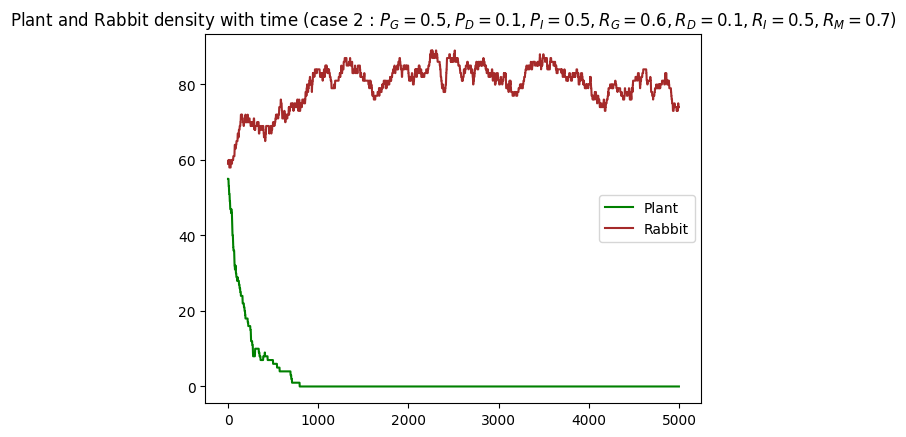

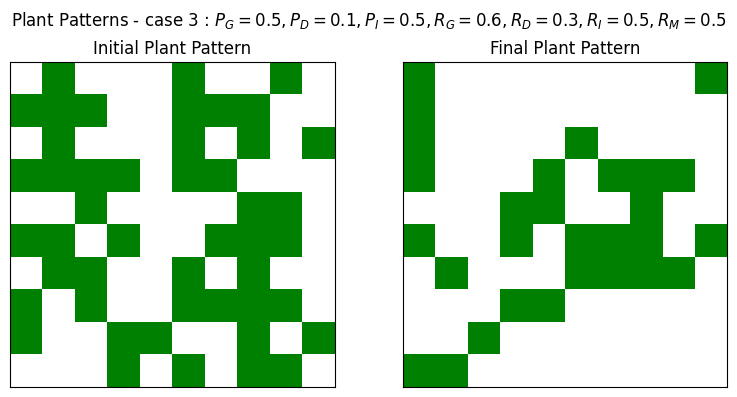

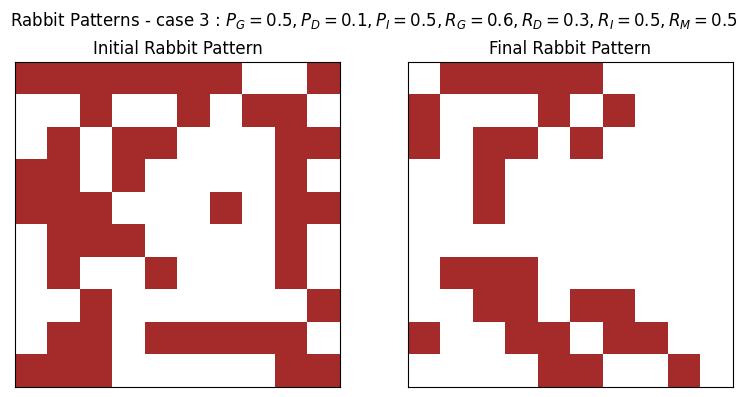

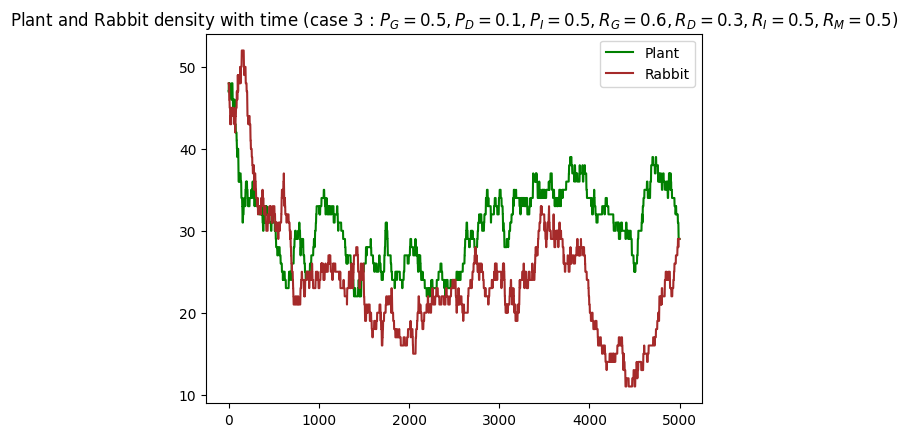

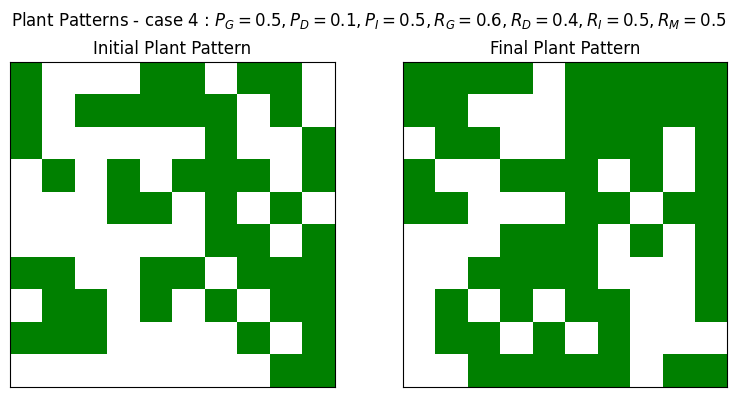

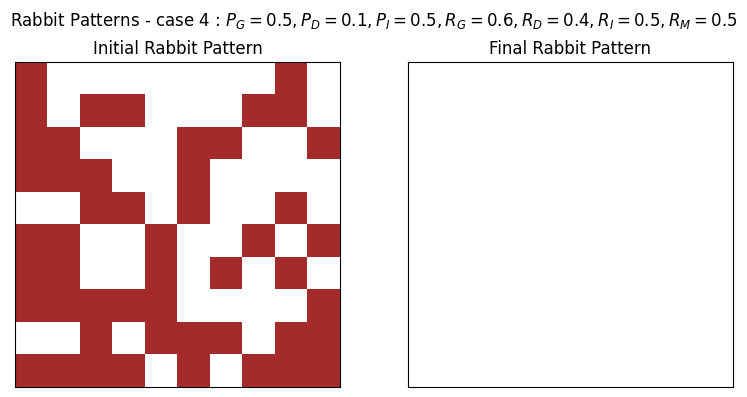

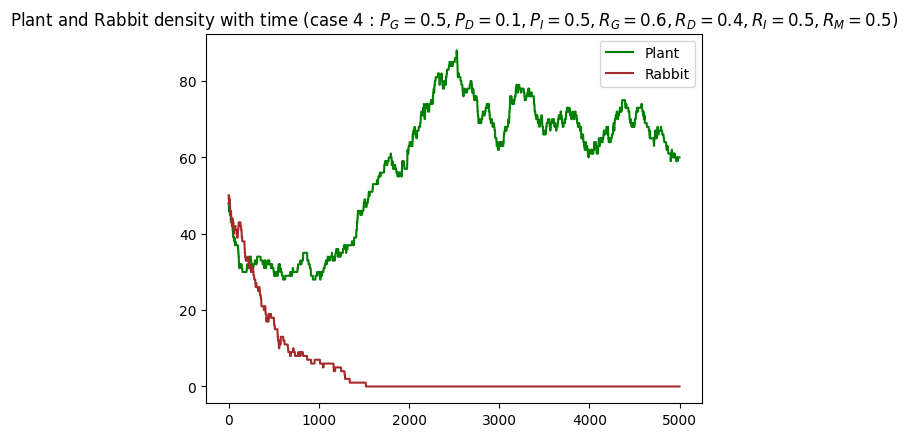

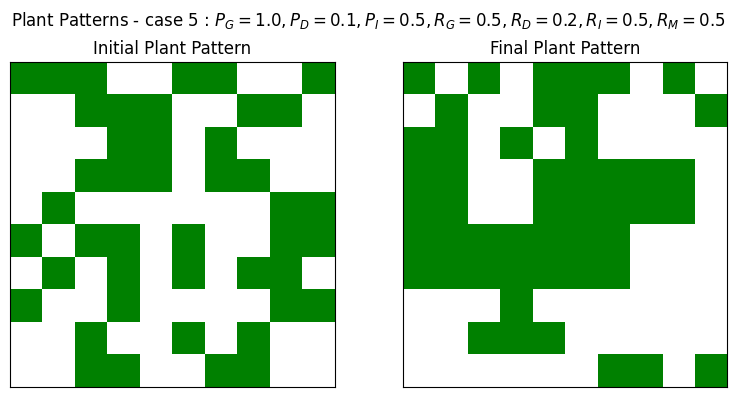

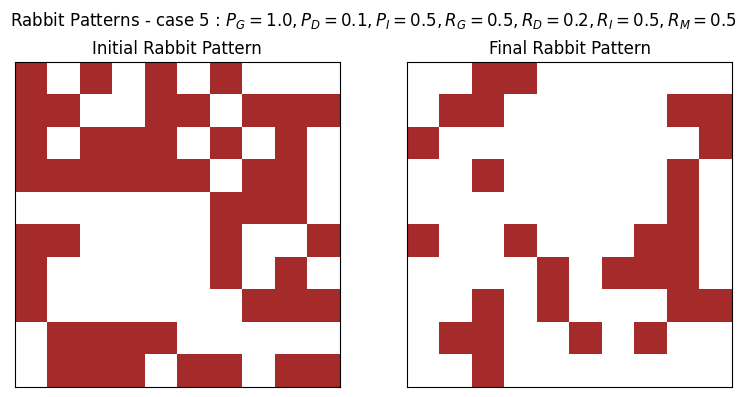

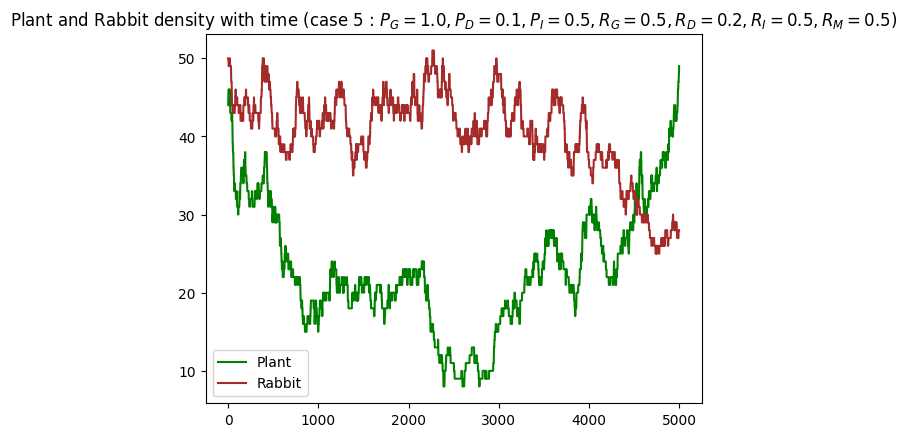

In [ ]:
def bc(i):
  if i < 0:
    return i + size
  elif i >= size:
    return i - size
  else:
    return i

casecount = 0
for case in cases:
  casecount += 1
  size = 10
  laststep = 5000

  # parameters of plants
  growthprob = case["params"]["growthprob"]
  deathprob = case["params"]["deathprob"]
  Plantinitial = case["params"]["Plantinitial"]

  # parameters of rabbits
  growthprobR = case["params"]["growthprobR"]
  deathprobR = case["params"]["deathprobR"]
  Rabbitinitial = case["params"]["Rabbitinitial"]
  moveprobR = case["params"]["moveprobR"]

  # list of plants
  habitat = [[0 for i in range(0, size)] for j in range(0, size)]
  # list of rabbits
  habitatR = [[0 for i in range(0, size)] for j in range(0, size)]

  Plantdensity = [None for i in range(0, laststep)]
  Rabbitdensity = [None for i in range(0, laststep)]
  time = [None for i in range(0, laststep)]

  # initial pattern
  for i in range(0, size):
    for j in range(0, size):
      r1 = random.random()
      r2 = random.random()
      if r1 < Plantinitial:
        habitat[i][j] = 1 # Plant
      if r2 < Rabbitinitial:
        habitatR[i][j] = 2 # rabbit

  # Store initial patterns for comparison after simulation
  initial_habitat_plant = copy.deepcopy(habitat)
  initial_habitat_rabbit = copy.deepcopy(habitatR)

  for t in range(0, laststep):
    # print("\n time =", t)

    # calculating the number of plant sites and rabbit sites
    Ptotal = 0 # the number of plants
    Rtotal = 0 # the number of rabbits
    for i in range(0, size):
      for j in range(0, size):
        if habitat[i][j] == 1:
          Ptotal = Ptotal + 1
        if habitatR[i][j] == 2:
          Rtotal = Rtotal + 1

    Plantdensity[t] = Ptotal
    Rabbitdensity[t] = Rtotal
    time[t] = t

    # Randomly select a site
    ii = random.randrange(0, size)
    jj = random.randrange(0, size)
    focal = habitat[ii][jj]
    focalR = habitatR[ii][jj]

    if focalR == 0: # no rabbit is in the site
      if focal == 1: # The plant is in the site
        if 1.0 - deathprob > random.random(): # the plant survives
          if growthprob > random.random(): # reproduction
            ic = random.randrange(-1, 2)
            jc = random.randrange(-1, 2)
            if ic*ic + jc*jc > 0:
              inext = bc(ii + ic)
              jnext = bc(jj + jc)
              if habitat[inext][jnext] == 0:
                habitat[inext][jnext] = 1 # a new plant grows
        else: # plant dies
          habitat[ii][jj] = 0

    elif focalR == 2: # The rabbit is in the site
      if 1.0 - deathprobR > random.random(): # Rabbit survive
        if focal == 1: # plant and rabbit are in the same site
          habitat[ii][jj] = 0 # The rabbit eats the plant

        # Reproduction
        ic = random.randrange(-1, 2)
        jc = random.randrange(-1, 2)
        if ic*ic + jc*jc > 0:
          inext = bc(ii + ic)
          jnext = bc(jj + jc)
          if habitatR[inext][jnext] == 0:
            if growthprobR > random.random(): # reproduction
              habitatR[inext][jnext] = 2 # a new-born rabbit

        # Movement
        if moveprobR > random.random(): # move or not
          ic = random.randrange(-1, 2)
          jc = random.randrange(-1, 2)
          if ic*ic + jc*jc > 0:
            inext = bc(ii + ic)
            jnext = bc(jj + jc)
            if habitatR[inext][jnext] == 0:
              habitatR[inext][jnext] = 2
              habitatR[ii][jj] = 0
      else:
        habitatR[ii][jj] = 0 # The rabbit dies


  # print(habitat)

  # initial and final plant patterns
  fig_p, axes_p = plt.subplots(1, 2, figsize=(8, 4))
  cmap_p = ListedColormap(['white', 'green'])

  axes_p[0].matshow(initial_habitat_plant, cmap=cmap_p)
  axes_p[0].set_title('Initial Plant Pattern')
  axes_p[0].set_xticks([])
  axes_p[0].set_yticks([])

  axes_p[1].matshow(habitat, cmap=cmap_p) # habitat holds the final state
  axes_p[1].set_title('Final Plant Pattern')
  axes_p[1].set_xticks([])
  axes_p[1].set_yticks([])

  fig_p.suptitle(f'Plant Patterns - case {casecount} : {case["label"]}') # Set overall title for the figure
  plt.tight_layout()
  plt.show()

  #print(habitatR)

  # initial and final rabbit patterns
  fig_r, axes_r = plt.subplots(1, 2, figsize=(8, 4))
  cmap_r = ListedColormap(['white', 'brown'])

  axes_r[0].matshow(initial_habitat_rabbit, cmap=cmap_r)
  axes_r[0].set_title('Initial Rabbit Pattern')
  axes_r[0].set_xticks([])
  axes_r[0].set_yticks([])

  axes_r[1].matshow(habitatR, cmap=cmap_r) # habitatR holds the final state
  axes_r[1].set_title('Final Rabbit Pattern')
  axes_r[1].set_xticks([])
  axes_r[1].set_yticks([])

  fig_r.suptitle(f'Rabbit Patterns - case {casecount} : {case["label"]}')
  plt.tight_layout()
  plt.show()

  # Original density plot
  plt.plot(time, Plantdensity, c="green", label='Plant')
  plt.plot(time, Rabbitdensity, c="brown", label='Rabbit')
  plt.title(f'Plant and Rabbit density with time (case {casecount} : {case["label"]})')
  plt.legend()
  # plt.savefig('densityPR.png')
  plt.show()


Case 2 is similar to Case 1, but Rabbit has a 0.7 chance to move, which overall causes the plant to die faster. Cases 3 and 4 have the rabbit move chance fixed at 0.5, with the only difference being the death chance for the rabbit, which is 0.3 in Case 3 and 0.4 in Case 4. This results in fluctuation between rabbits and plants in case 3, and in case 4, rabbits go extinct. Lastly, in case 5, the rabbit death chance is set to 0.2, and the plant growth chance is set to 1.0. The result is as expected: plants will try to grow, but the population will drop when the rabbit population grows too much.

---

### Extending the model with a predator (fox)

Creating cases for parameters

In [4]:
cases = [
  {
    "label": "Case 1",
    "params": dict(growthprob = 0.5, deathprob = 0.1, Plantinitial = 0.5, growthprobR = 0.6, deathprobR = 0.1, Rabbitinitial = 0.5, moveprobR = 0, moveDistanceR = 3, growthprobF = 0.5, deathprobF = 0.1, Foxinitial = 0.02, moveprobF = 0.5, moveDistanceF = 3)
  },
  {
    "label": "Case 2",
    "params": dict(growthprob = 0.5, deathprob = 0.1, Plantinitial = 0.5, growthprobR = 0.6, deathprobR = 0.1, Rabbitinitial = 0.5, moveprobR = 0.7, moveDistanceR = 4, growthprobF = 0.6, deathprobF = 0.15, Foxinitial = 0.03, moveprobF = 0.6, moveDistanceF = 4)
  },
  {
    "label": "Case 3",
    "params": dict(growthprob = 0.5, deathprob = 0.1, Plantinitial = 0.5, growthprobR = 0.6, deathprobR = 0.3, Rabbitinitial = 0.5, moveprobR = 0.5, moveDistanceR = 3, growthprobF = 0.55, deathprobF = 0.2, Foxinitial = 0.04, moveprobF = 0.5, moveDistanceF = 5)
  },
  {
    "label": "Case 4",
    "params": dict(growthprob = 0.5, deathprob = 0.1, Plantinitial = 0.5, growthprobR = 0.6, deathprobR = 0.4, Rabbitinitial = 0.5, moveprobR = 0.5, moveDistanceR = 2, growthprobF = 0.5, deathprobF = 0.25, Foxinitial = 0.05, moveprobF = 0.5, moveDistanceF = 4)
  },
  {
    "label": "Case 5",
    "params": dict(growthprob = 1.0, deathprob = 0.1, Plantinitial = 0.5, growthprobR = 0.5, deathprobR = 0.2, Rabbitinitial = 0.5, moveprobR = 0.5, moveDistanceR = 3, growthprobF = 0.6, deathprobF = 0.2, Foxinitial = 0.03, moveprobF = 0.6, moveDistanceF = 3)
  }
]

Begin to modify the code

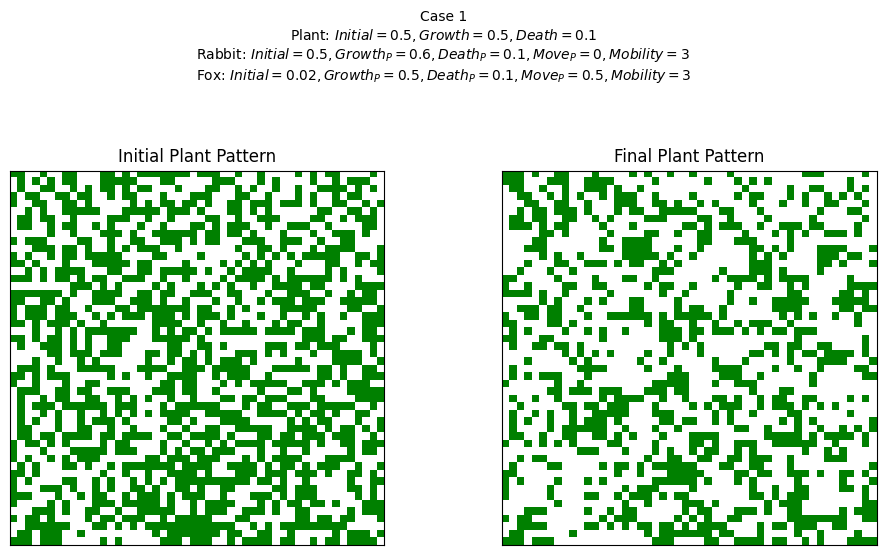

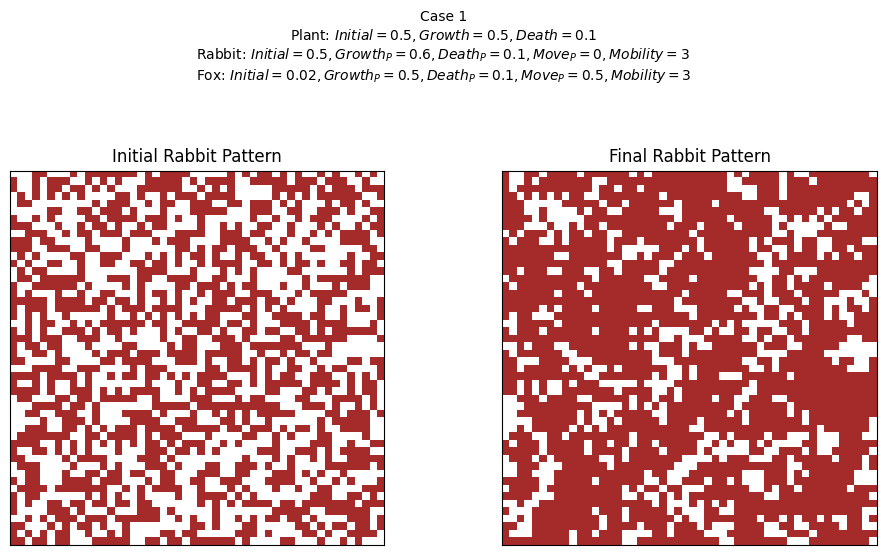

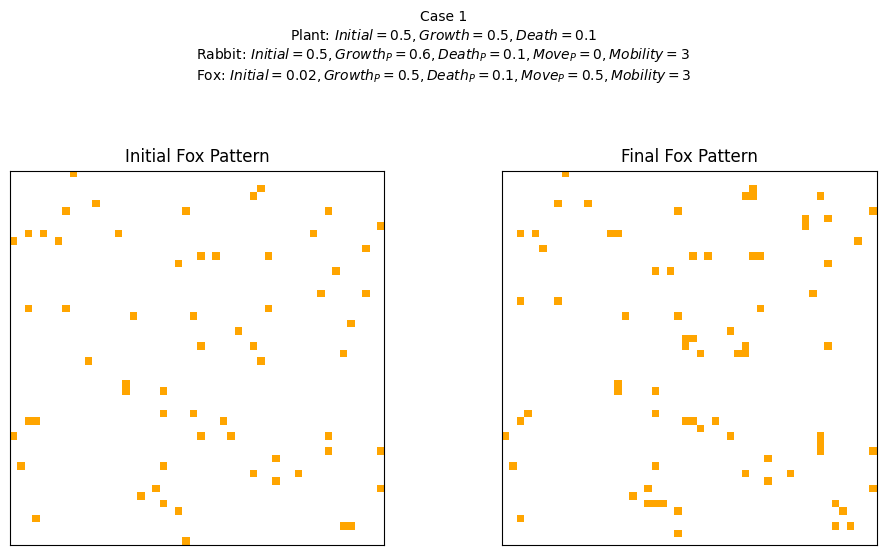

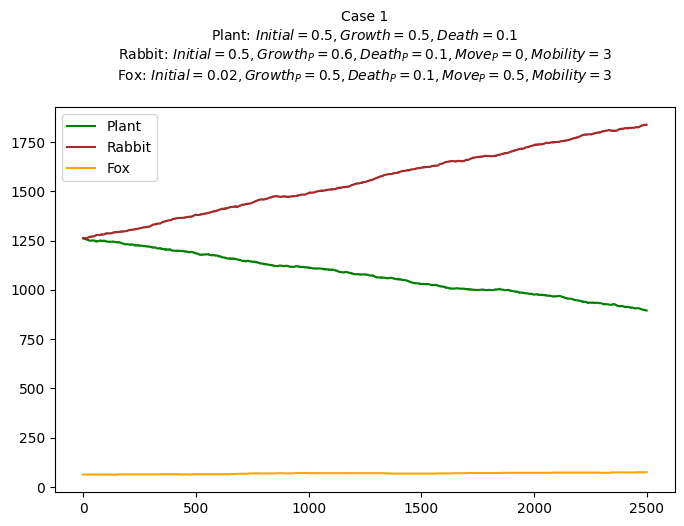

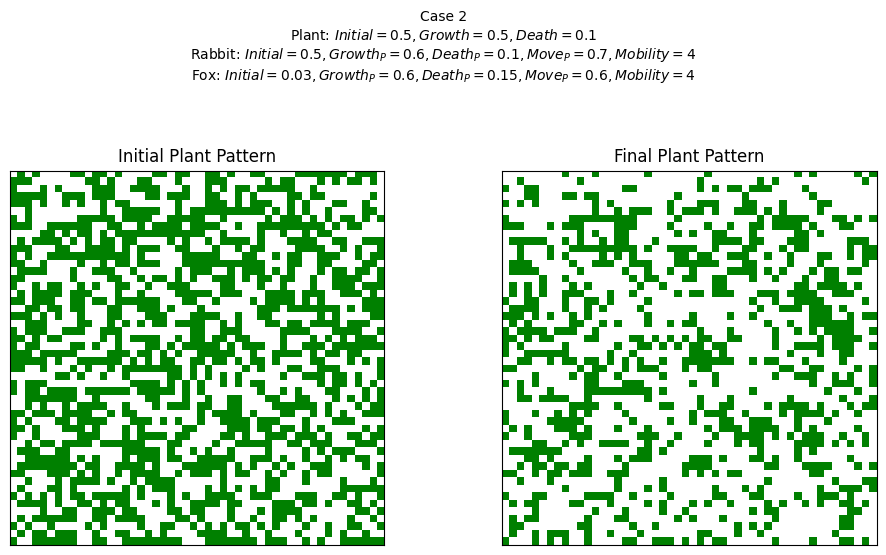

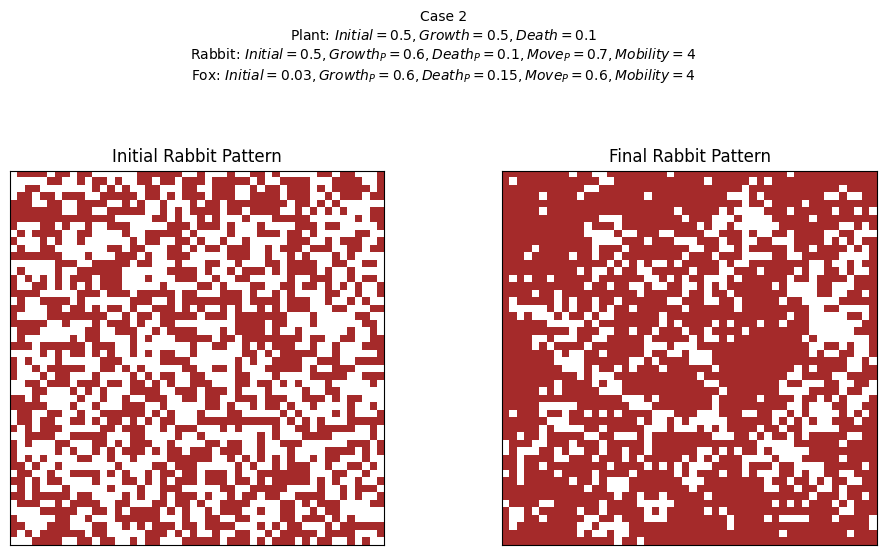

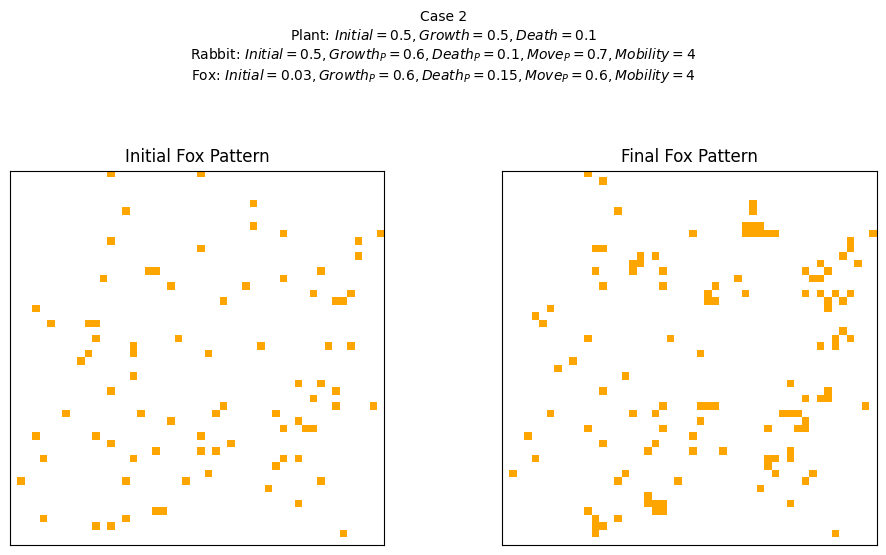

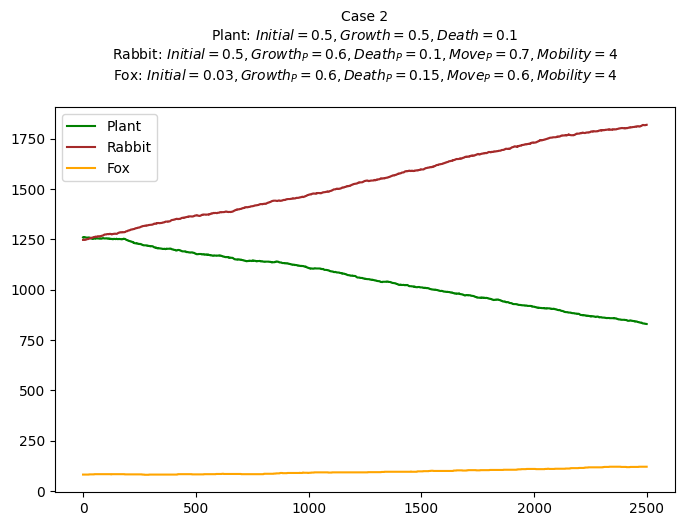

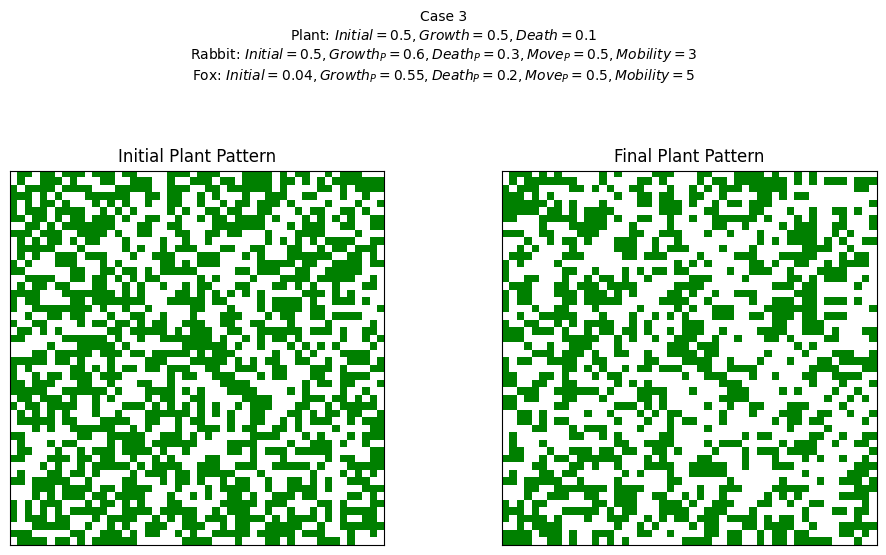

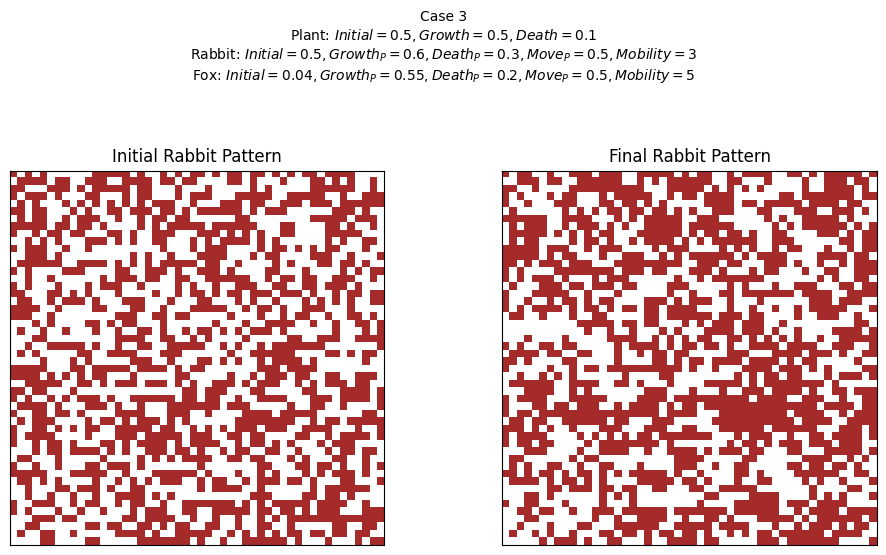

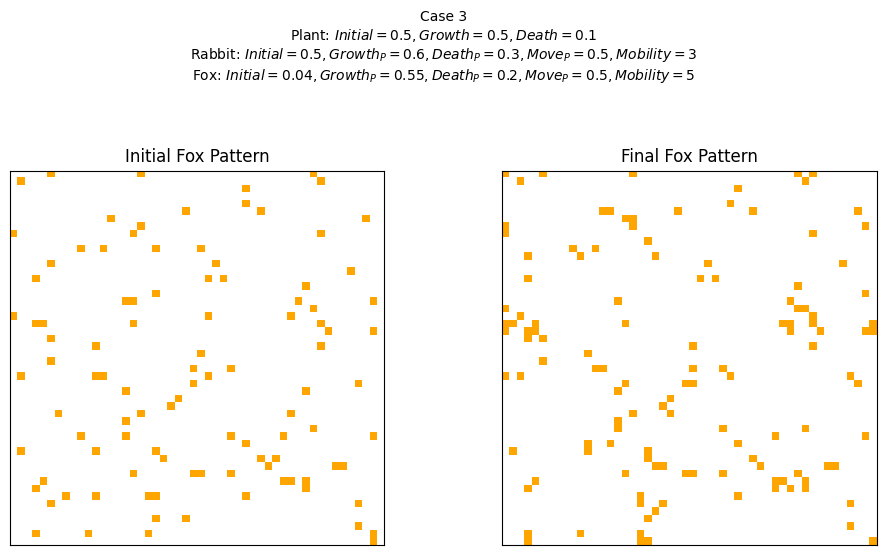

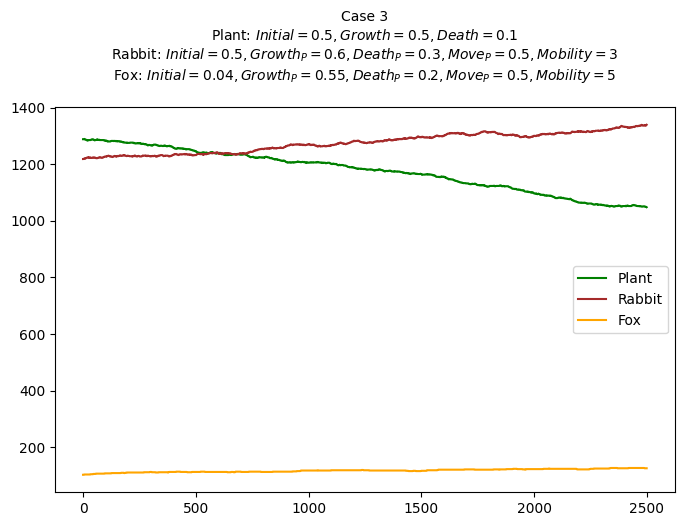

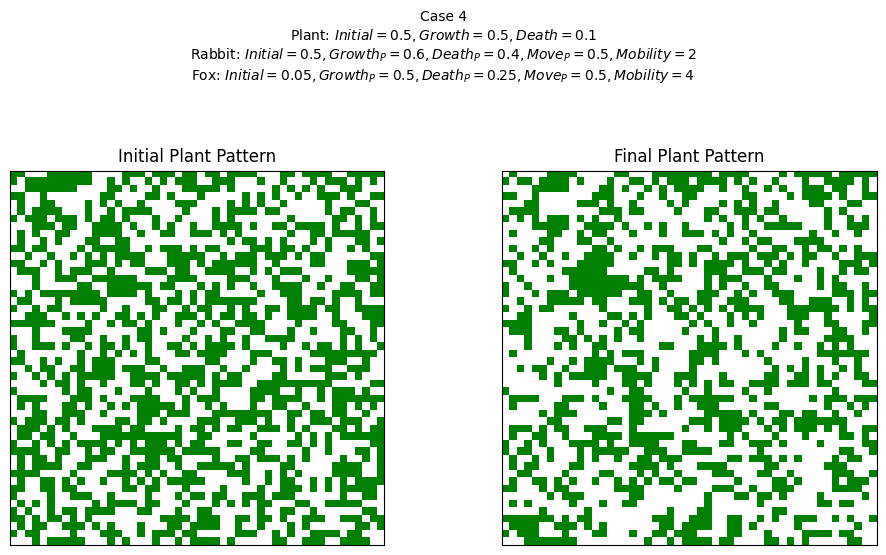

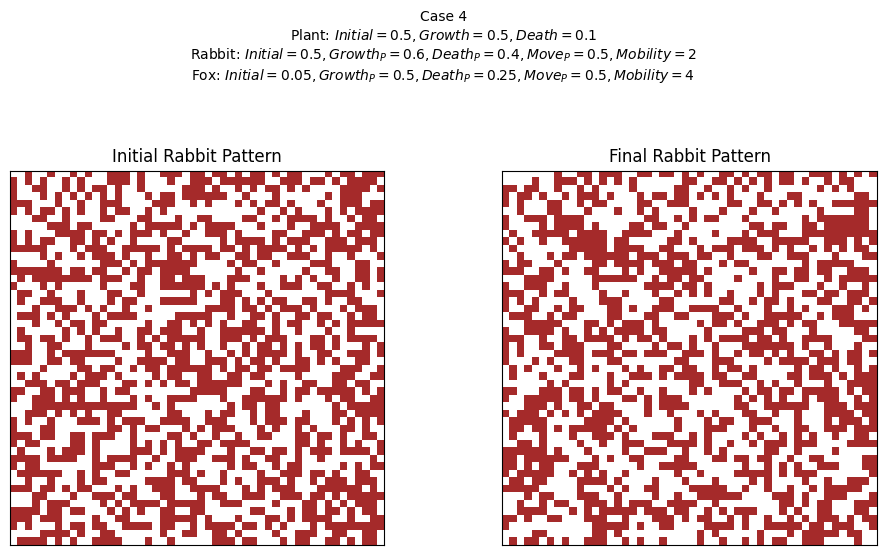

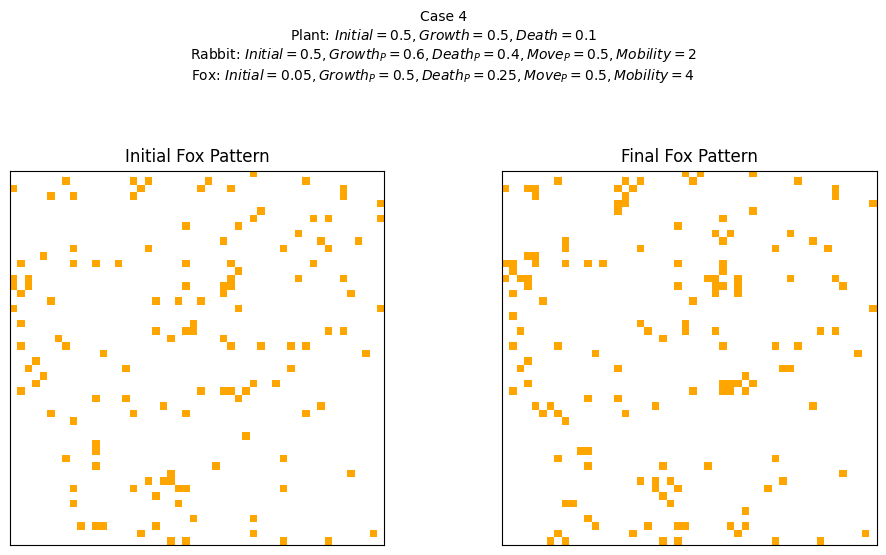

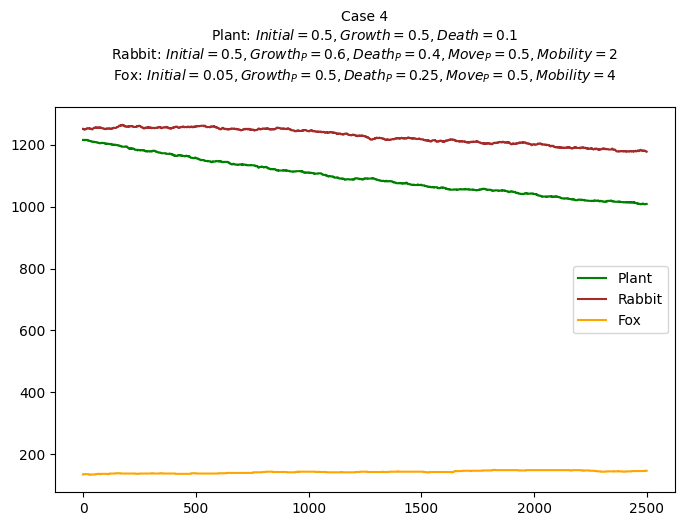

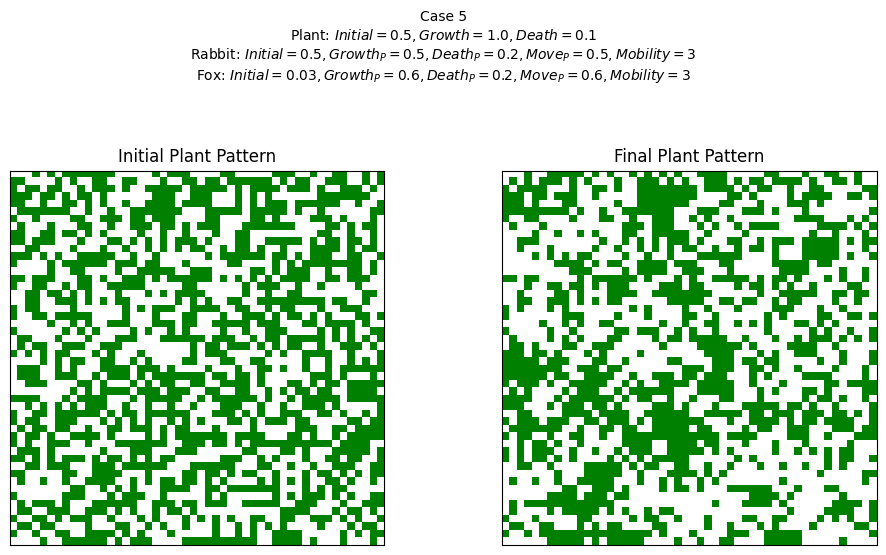

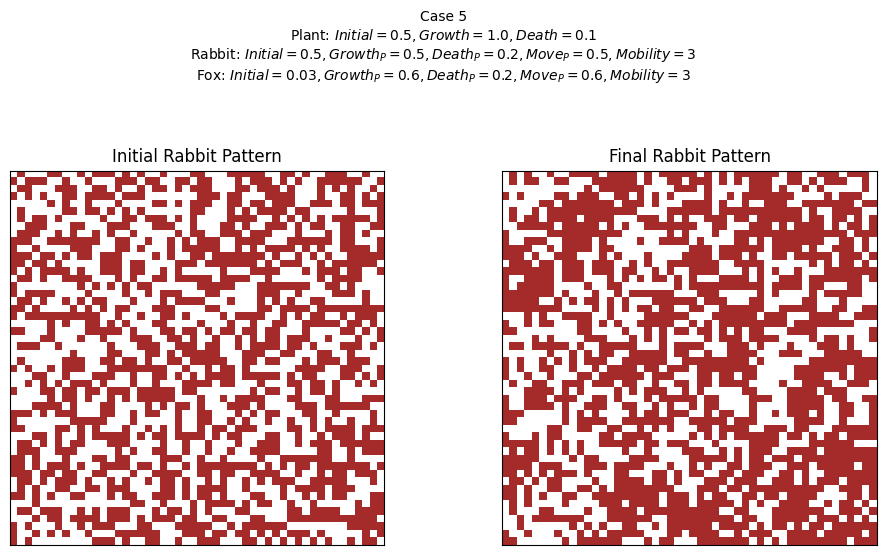

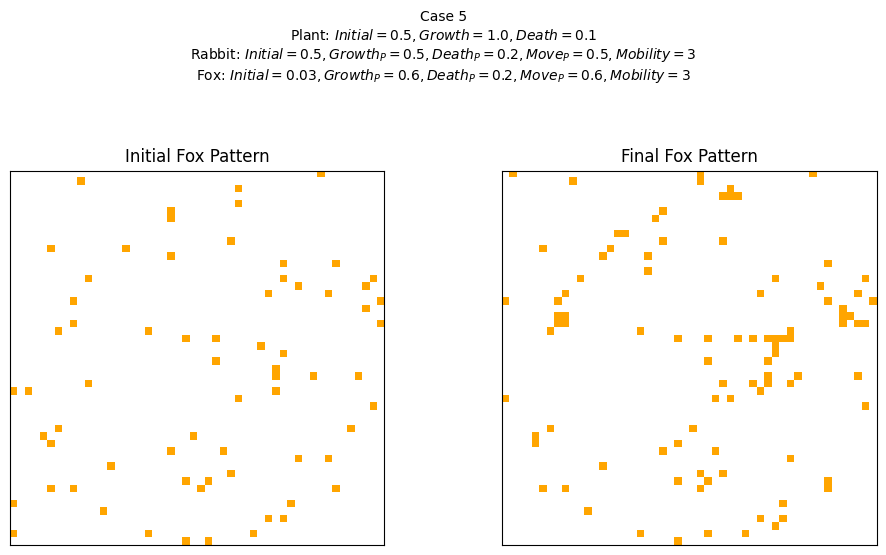

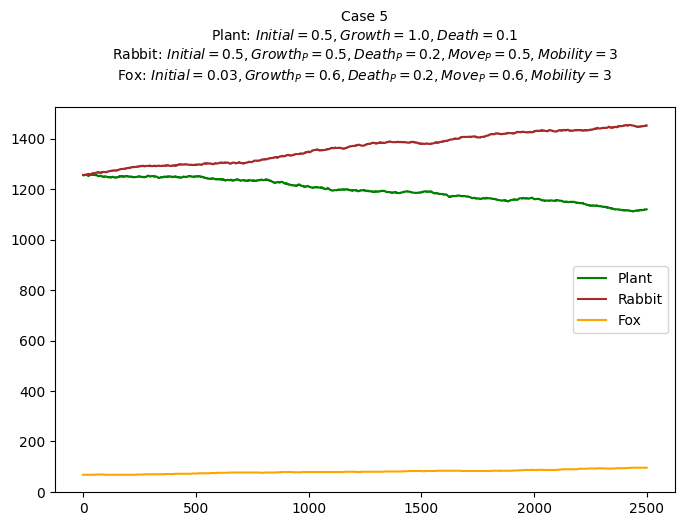

In [ ]:
def bc(i):
  if i < 0:
    return i + size
  elif i >= size:
    return i - size
  else:
    return i

casecount = 0
for case in cases:
  casecount += 1
  size = 50
  laststep = 2500

  # parameters of plants
  growthprob = case["params"]["growthprob"]
  deathprob = case["params"]["deathprob"]
  Plantinitial = case["params"]["Plantinitial"]

  # parameters of rabbits
  growthprobR = case["params"]["growthprobR"]
  deathprobR = case["params"]["deathprobR"]
  Rabbitinitial = case["params"]["Rabbitinitial"]
  moveprobR = case["params"]["moveprobR"]
  moveDistanceR = case["params"]["moveDistanceR"]

  # parameters of foxs
  growthprobF = case["params"]["growthprobF"]
  deathprobF = case["params"]["deathprobF"]
  Foxinitial = case["params"]["Foxinitial"]
  moveprobF = case["params"]["moveprobF"]
  moveDistanceF = case["params"]["moveDistanceF"]

  case_label = (
      f"Case {casecount}\n"
      f"Plant: $Initial={Plantinitial}, Growth={growthprob}, Death={deathprob}$\n"
      f"Rabbit: $Initial={Rabbitinitial}, Growth_P={growthprobR}, Death_P={deathprobR}, Move_P={moveprobR}, Mobility={moveDistanceR}$\n"
      f"Fox: $Initial={Foxinitial}, Growth_P={growthprobF}, Death_P={deathprobF}, Move_P={moveprobF}, Mobility={moveDistanceF}$"
  )

  # list of plants
  habitat = [[0 for i in range(0, size)] for j in range(0, size)]
  # list of rabbits
  habitatR = [[0 for i in range(0, size)] for j in range(0, size)]
  # list of foxes
  habitatF = [[0 for i in range(0, size)] for j in range(0, size)]

  Plantdensity = [None for i in range(0, laststep)]
  Rabbitdensity = [None for i in range(0, laststep)]
  Foxdensity = [None for i in range(0, laststep)]
  time = [None for i in range(0, laststep)]

  # initial pattern
  for i in range(0, size):
    for j in range(0, size):
      r1 = random.random()
      r2 = random.random()
      r3 = random.random()
      if r1 < Plantinitial:
        habitat[i][j] = 1 # Plant
      if r2 < Rabbitinitial:
        habitatR[i][j] = 2 # rabbit
      if r3 < Foxinitial:
        habitatF[i][j] = 3 # fox

  # Store initial patterns for comparison after simulation
  initial_habitat_plant = copy.deepcopy(habitat)
  initial_habitat_rabbit = copy.deepcopy(habitatR)
  initial_habitat_fox = copy.deepcopy(habitatF)

  for t in range(0, laststep):
    # print("\n time =", t)

    # calculating the number of plant sites and rabbit sites
    Ptotal = 0 # the number of plants
    Rtotal = 0 # the number of rabbits
    Ftotal = 0 # the number of foxs
    for i in range(0, size):
      for j in range(0, size):
        if habitat[i][j] == 1:
          Ptotal = Ptotal + 1
        if habitatR[i][j] == 2:
          Rtotal = Rtotal + 1
        if habitatF[i][j] == 3:
          Ftotal = Ftotal + 1

    Plantdensity[t] = Ptotal
    Rabbitdensity[t] = Rtotal
    Foxdensity[t] = Ftotal
    time[t] = t

    # Randomly select a site
    ii = random.randrange(0, size)
    jj = random.randrange(0, size)
    focal = habitat[ii][jj]
    focalR = habitatR[ii][jj]
    focalF = habitatF[ii][jj]

    if focalF == 0: # no fox is in the site
      if focalR == 0: # no rabbit is in the site
        if focal == 1: # The plant is in the site
          if 1.0 - deathprob > random.random(): # the plant survives
            if random.random() < growthprob: # (Modify)
              empty_spots = []
              for dx in range(-1, 2):
                for dy in range(-1, 2):
                  if dx == 0 and dy == 0:
                    continue # Skip the parent plant's own spot

                  ni, nj = bc(ii + dx), bc(jj + dy)
                  if habitat[ni][nj] == 0:
                    empty_spots.append((ni, nj))

              if empty_spots:
                birth_spot = random.choice(empty_spots)
                habitat[birth_spot[0]][birth_spot[1]] = 1
          else: # plant dies
            habitat[ii][jj] = 0

      elif focalR == 2: # The rabbit is in the site
        if 1.0 - deathprobR > random.random(): # Rabbit survive
          if focal == 1: # plant and rabbit are in the same site
            habitat[ii][jj] = 0 # The rabbit eats the plant

          # Reproduction (Modify)
          if growthprobR > random.random(): # reproduction
            empty_neighbors = []
            for dx in range(-1, 2):
              for dy in range(-1, 2):
                if dx == 0 and dy == 0:
                  continue # Skip parent's spot
                ni, nj = bc(ii + dx), bc(jj + dy)
                if habitatR[ni][nj] == 0 and habitatF[ni][nj] == 0: # only consider place that got no rabbit and fox
                  empty_neighbors.append((ni, nj))
            if empty_neighbors: # True if non-empty
              birth_spot = random.choice(empty_neighbors)
              habitatR[birth_spot[0]][birth_spot[1]] = 2

          # choose a destination within moveDistanceR (Modify)
          if moveprobR > random.random():
            # collect all empty candidate cells within radius
            candidates = []
            foxes = []
            for dx in range(-moveDistanceR, moveDistanceR+1): #check the cells
              for dy in range(-moveDistanceR, moveDistanceR+1): #create Rabbit detector
                if dx == 0 and dy == 0:
                  continue #Don't choose the position standing
                if dx*dx + dy*dy <= moveDistanceR*moveDistanceR:
                  ni = bc(ii + dx)
                  nj = bc(jj + dy)
                  if habitatR[ni][nj] == 0:
                    candidates.append((ni, nj))
                  if habitatF[ni][nj] == 3: # detect foxes
                    foxes.append((ni, nj))

            if foxes and candidates:
              # If fox nearby, choose candidate that maximizes distance to nearest fox
              best = None
              max_safety = -1 # So the 1st dist_to_nearest will be the farthest distance
              for (ci, cj) in candidates:
                # 1. Find how close the nearest fox is to this candidate spot
                dist_to_nearest_fox = np.inf # So the 1st fox will be the nearest fox
                for (fi, fj) in foxes:
                  d2 = (ci - fi)**2 + (cj - fj)**2 #distance^2
                  if d2 < dist_to_nearest_fox:
                    dist_to_nearest_fox = d2 # get the clostest fox distance^2
                if dist_to_nearest_fox > max_safety: #max_safety store farthest distance
                  max_safety = dist_to_nearest_fox
                  best = (ci, cj) #will store best coordinate only when find better position that get distance farther than the one store in max_safety
              if best:
                habitatR[best[0]][best[1]] = 2
                habitatR[ii][jj] = 0
            elif candidates:
              # No nearby fox: pick a random empty candidate
              ni, nj = random.choice(candidates)
              habitatR[ni][nj] = 2
              habitatR[ii][jj] = 0
            else:
              # no empty cell available -> stay
              pass
        else:
          habitatR[ii][jj] = 0 # The rabbit dies
    elif focalF == 3: # The fox is in the site
      # Fox survival
      if 1.0 - deathprobF > random.random():
        # If rabbit present in same site, fox eats it
        if focalR == 2:
          habitatR[ii][jj] = 0

        # Reproduction to nearby empty cell (Modify)
        if random.random() < growthprobF:
          empty_fox_spots = []
          for dx in range(-1, 2):
            for dy in range(-1, 2):
              if dx == 0 and dy == 0:
                continue # Skip the parent fox's own spot

              ni, nj = bc(ii + dx), bc(jj + dy)
              if habitatF[ni][nj] == 0:
                empty_fox_spots.append((ni, nj))
          if empty_fox_spots:
            birth_spot = random.choice(empty_fox_spots)
            habitatF[birth_spot[0]][birth_spot[1]] = 3

        # chase nearest rabbit within moveDistanceF
        if moveprobF > random.random():
          # find nearest rabbit within radius
          grid_size = len(habitatR) #Fox got full vision of the map
          nearest = None
          nearest_d2 = None
          for ni in range(grid_size):
            for nj in range(grid_size):
              if habitatR[ni][nj] == 2:
                dx = ni - ii
                dy = nj - jj

                if dx > grid_size / 2:
                  dx -= grid_size
                elif dx < -grid_size / 2:
                  dx += grid_size

                if dy > grid_size / 2:
                  dy -= grid_size
                elif dy < -grid_size / 2:
                  dy += grid_size
                d2 = dx*dx + dy*dy

                if nearest_d2 is None or d2 < nearest_d2:
                  nearest_d2 = d2
                  nearest = (ni, nj, dx, dy)

          if nearest:
            # move one step towards the rabbit (clamp dx,dy to -1..1)
            step_x = 0 if nearest[2] == 0 else (1 if nearest[2] > 0 else -1)
            step_y = 0 if nearest[3] == 0 else (1 if nearest[3] > 0 else -1)
            ni = bc(ii + step_x)
            nj = bc(jj + step_y)
            if habitatF[ni][nj] == 0:
              habitatF[ni][nj] = 3
              habitatF[ii][jj] = 0
          else:
            # no rabbit detected nearby: random walk within one cell
            ic = random.randrange(-1, 2)
            jc = random.randrange(-1, 2)
            if ic*ic + jc*jc > 0:
              ni = bc(ii + ic)
              nj = bc(jj + jc)
              if habitatF[ni][nj] == 0:
                habitatF[ni][nj] = 3
                habitatF[ii][jj] = 0
      else:
        habitatF[ii][jj] = 0


  # print(habitat)

  # initial and final plant patterns
  fig_p, axes_p = plt.subplots(1, 2, figsize=(10, 5))
  cmap_p = ListedColormap(['white', 'green'])

  axes_p[0].matshow(initial_habitat_plant, cmap=cmap_p)
  axes_p[0].set_title('Initial Plant Pattern')
  axes_p[0].set_xticks([])
  axes_p[0].set_yticks([])

  axes_p[1].matshow(habitat, cmap=cmap_p) # habitat holds the final state
  axes_p[1].set_title('Final Plant Pattern')
  axes_p[1].set_xticks([])
  axes_p[1].set_yticks([])

  fig_p.suptitle(case_label, fontsize=10, y=1.10)
  plt.tight_layout()
  plt.show()

  #print(habitatR)

  # initial and final rabbit patterns
  fig_r, axes_r = plt.subplots(1, 2, figsize=(10, 5))
  cmap_r = ListedColormap(['white', 'brown'])

  axes_r[0].matshow(initial_habitat_rabbit, cmap=cmap_r)
  axes_r[0].set_title('Initial Rabbit Pattern')
  axes_r[0].set_xticks([])
  axes_r[0].set_yticks([])

  axes_r[1].matshow(habitatR, cmap=cmap_r) # habitatR holds the final state
  axes_r[1].set_title('Final Rabbit Pattern')
  axes_r[1].set_xticks([])
  axes_r[1].set_yticks([])

  fig_r.suptitle(case_label, fontsize=10, y=1.10)
  plt.tight_layout()
  plt.show()

  # initial and final fox patterns
  fig_f, axes_f = plt.subplots(1, 2, figsize=(10, 5))
  cmap_f = ListedColormap(['white', 'orange'])

  axes_f[0].matshow(initial_habitat_fox, cmap=cmap_f)
  axes_f[0].set_title('Initial Fox Pattern')
  axes_f[0].set_xticks([])
  axes_f[0].set_yticks([])

  axes_f[1].matshow(habitatF, cmap=cmap_f) # habitatF holds the final state
  axes_f[1].set_title('Final Fox Pattern')
  axes_f[1].set_xticks([])
  axes_f[1].set_yticks([])

  fig_f.suptitle(case_label, fontsize=10, y=1.10)
  plt.tight_layout()
  plt.show()

  # Density plot
  plt.figure(figsize=(8, 5))
  plt.plot(time, Plantdensity, c="green", label='Plant')
  plt.plot(time, Rabbitdensity, c="brown", label='Rabbit')
  plt.plot(time, Foxdensity, c="orange", label='Fox')
  plt.title(case_label, fontsize=10, y=1.05)
  plt.legend()
  # plt.savefig(f'densityPRF_case{casecount}.png')
  plt.show()

---

### Modify details of plant-rabbit-fox model

The modification of the model from plant-rabbit model to plant-rabbit-fox model includes:

- Adding Fox

Create a predator with a low initial population to keep the food chain balanced.

- Reproduction part

The plant-rabbit baseline model uses the following reproduction step:

```
ic = random.randrange(-1, 2)
jc = random.randrange(-1, 2)
  if ic*ic + jc*jc > 0:
    inext = bc(ii + ic)
    jnext = bc(jj + jc)
    if habitatR[inext][jnext] == 0:
      if growthprobR > random.random():
        habitatR[inext][jnext] = 2
```
This doesn't apply `growthprobR` the way the variable name implies: because a neighbor cell is chosen before the probability is tested, a site with fewer empty neighbors ends up with a lower reproduction chance than one surrounded by empty cells.

Therefore, the modified code is as follows:

```
# Reproduction (Modify)
if growthprobR > random.random(): # reproduction
  empty_neighbors = []
  for dx in range(-1, 2):
    for dy in range(-1, 2):
      if dx == 0 and dy == 0:
        continue # Skip parent's spot
      ni, nj = bc(ii + dx), bc(jj + dy)
      if habitatR[ni][nj] == 0 and habitatF[ni][nj] == 0: # only consider place that got no rabbit and fox
        empty_neighbors.append((ni, nj))
  if empty_neighbors: # True if non-empty
    birth_spot = random.choice(empty_neighbors)
    habitatR[birth_spot[0]][birth_spot[1]] = 2
```

Now the code will store empty neighbors first, then use the `growthprobR` variable, then randomly select from the `empty_neighbors` list. For the rabbit, it will also consider the place that got rabbit and the fox are not empty. Then, I modified similiar thing for plants' and foxes' reproduction.

 - Movement part

In the plant-rabbit model, the movement is already random, but now Rabbits will move randomly only in the limited `moveDistanceR`. Moreover, rabbits will move to the farthest cells from the closest fox possible.

Rabbit will compare the blank cells and the cell that got foxes. They calculate the furthest possible cells within moving range and store them in temporaly `max_safety` variable to compare and selected the safest position and choose to move there.

While foxes will always move toward the nearest rabbits across the grid.